# Loading the dataset

## Import Required Libraries
Import necessary libraries for data analysis, including pandas and numpy.

In [20]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## Extract Dataset
Extract the dataset from the compressed zip file.

In [21]:
import zipfile
import os

# Extract the dataset from the zip file
zip_file_path = 'ag-news-classification-dataset.zip'
extract_path = './ag-news-classification-dataset'

# Check if the dataset has already been extracted
if os.path.exists(extract_path):
    print("Dataset already extracted. Skipping extraction.")
else:
    # Extract only if the folder doesn't exist
    if os.path.exists(zip_file_path):
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall('./')
        print("Dataset extracted successfully!")
    else:
        print(f"Zip file not found at {zip_file_path}")

# List extracted files
extracted_files = os.listdir('./')
print("\nExtracted files:")
for file in extracted_files:
    print(f"  - {file}")

Zip file not found at ag-news-classification-dataset.zip

Extracted files:
  - .DS_Store
  - .gitkeep
  - playbook.ipynb
  - agnews


## Load Dataset into DataFrame
Load the AG News dataset into a Pandas DataFrame for analysis.

In [22]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# The train.csv / test.csv files live in the "agnews" folder.
DATA_DIR = 'agnews'

# IMPORTANT: the CSVs have a header row ("Class Index,Title,Description").
# header=0 consumes that real header; `names` then sets clean column names.
# Casting Class Index to int is what makes the label logic downstream work.
df_train = pd.read_csv(f'{DATA_DIR}/train.csv', header=0,
                       names=['Class Index', 'Title', 'Description'])
df_test  = pd.read_csv(f'{DATA_DIR}/test.csv',  header=0,
                       names=['Class Index', 'Title', 'Description'])

df_train['Class Index'] = df_train['Class Index'].astype(int)
df_test['Class Index']  = df_test['Class Index'].astype(int)

print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")
print(f"Class Index dtype: {df_train['Class Index'].dtype}")
print(f"Class Index values: {sorted(df_train['Class Index'].unique())}")
print(df_train.head(2))

Train shape: (120000, 3)
Test shape:  (7600, 3)
Class Index dtype: int64
Class Index values: [1, 2, 3, 4]
   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  


## Dataset Overview
Display the basic information and structure of the loaded dataset.

In [23]:
def display_dataframe_info(df, name):
    """Display detailed information about a dataframe"""
    print(f"\n{'='*60}")
    print(f"DATASET: {name}")
    print(f"{'='*60}")
    print(f"Shape: {df.shape}")
    
    print("\n" + "="*60)
    print("First Few Rows:")
    print("="*60)
    print(df.head())
    
    print("\n" + "="*60)
    print("Column Information:")
    print("="*60)
    print(df.info())
    
    print("\n" + "="*60)
    print("Summary Statistics:")
    print("="*60)
    print(df.describe())
    
    print("\n" + "="*60)
    print("Missing Values:")
    print("="*60)
    print(df.isnull().sum())

# Display info for all loaded datasets
if df_train is not None:
    display_dataframe_info(df_train, "Training Data")

if df_test is not None:
    display_dataframe_info(df_test, "Test Data")

if df_train is None and df_test is None:
    print("No datasets loaded successfully.")


DATASET: Training Data
Shape: (120000, 3)

First Few Rows:
   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       ----

# Exploratory Data Analysis (EDA)

## Class Distribution
Analyze the distribution of news categories in both training and test datasets.

In [24]:
import matplotlib.pyplot as plt

binary_mapping = {0: "Non-Sports", 1: "Sports"}

def add_binary_label(df):
    df = df.copy()
    # AG News class 2 = Sports. Cast to int so the comparison is numeric,
    # not a string-vs-int compare (which would silently make every label 0).
    df['label'] = (df['Class Index'].astype(int) == 2).astype(int)
    return df

df_train = add_binary_label(df_train)
df_test  = add_binary_label(df_test)

def analyze_class_distribution(df, name):
    print(f"\n{'='*60}")
    print(f"CLASS DISTRIBUTION: {name}")
    print(f"{'='*60}")
    counts = df['label'].value_counts().sort_index()
    percentages = (counts / len(df) * 100).round(2)
    print("\nClass Counts:")
    for lbl in sorted(counts.index):
        print(f"  {lbl} - {binary_mapping[lbl]}: {counts[lbl]:,} ({percentages[lbl]}%)")
    return counts, percentages

train_counts, train_percentages = analyze_class_distribution(df_train, "Training Data")
test_counts,  test_percentages  = analyze_class_distribution(df_test,  "Test Data")


CLASS DISTRIBUTION: Training Data

Class Counts:
  0 - Non-Sports: 90,000 (75.0%)
  1 - Sports: 30,000 (25.0%)

CLASS DISTRIBUTION: Test Data

Class Counts:
  0 - Non-Sports: 5,700 (75.0%)
  1 - Sports: 1,900 (25.0%)


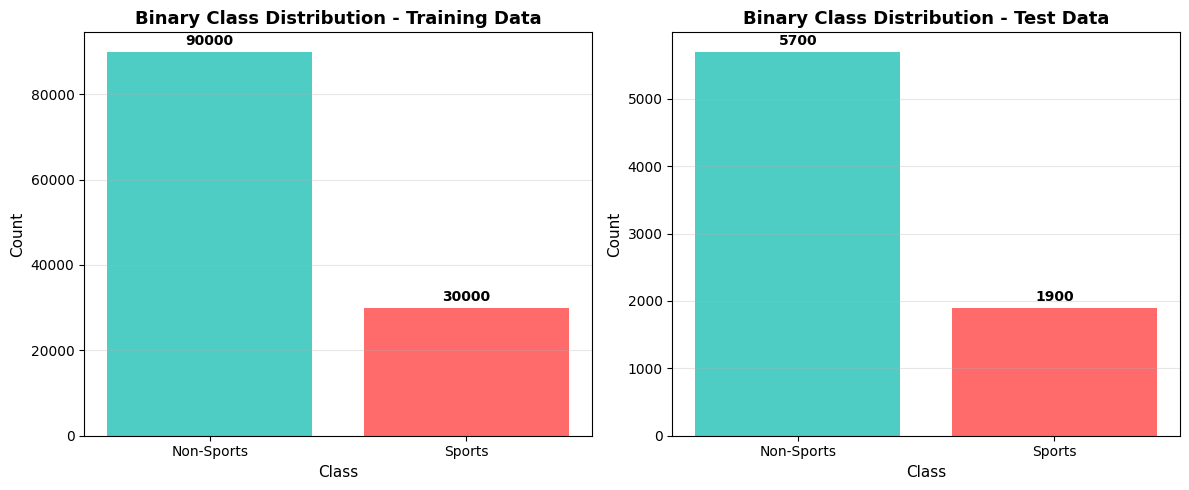


 Binary class distribution analysis complete!


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4ECDC4', '#FF6B6B']

for ax, (counts, title) in zip(axes, [(train_counts, 'Training Data'), (test_counts, 'Test Data')]):
    labels = [binary_mapping[i] for i in sorted(counts.index)]
    ax.bar(labels, counts.values, color=colors)
    ax.set_title(f'Binary Class Distribution - {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    for j, v in enumerate(counts.values):
        ax.text(j, v + max(counts.values)*0.01, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
print("\n Binary class distribution analysis complete!")

## Text Length Distribution
Analyze the distribution of text lengths (Title and Description) in both datasets.

In [26]:
# Calculate text lengths for both datasets
def calculate_text_lengths(df, name):
    """Calculate and display text length statistics"""
    print(f"\n{'='*60}")
    print(f"TEXT LENGTH DISTRIBUTION: {name}")
    print(f"{'='*60}")
    
    # Calculate lengths
    df_copy = df.copy()
    df_copy['Title_Length'] = df_copy['Title'].str.len()
    df_copy['Description_Length'] = df_copy['Description'].str.len()
    
    # Display statistics for Title
    print(f"\nTitle Length Statistics:")
    print(f"  Mean: {df_copy['Title_Length'].mean():.2f}")
    print(f"  Median: {df_copy['Title_Length'].median():.2f}")
    print(f"  Min: {df_copy['Title_Length'].min()}")
    print(f"  Max: {df_copy['Title_Length'].max()}")
    print(f"  Std Dev: {df_copy['Title_Length'].std():.2f}")
    
    # Display statistics for Description
    print(f"\nDescription Length Statistics:")
    print(f"  Mean: {df_copy['Description_Length'].mean():.2f}")
    print(f"  Median: {df_copy['Description_Length'].median():.2f}")
    print(f"  Min: {df_copy['Description_Length'].min()}")
    print(f"  Max: {df_copy['Description_Length'].max()}")
    print(f"  Std Dev: {df_copy['Description_Length'].std():.2f}")
    
    return df_copy

# Calculate for both datasets
df_train_text = calculate_text_lengths(df_train, "Training Data")
df_test_text = calculate_text_lengths(df_test, "Test Data")


TEXT LENGTH DISTRIBUTION: Training Data

Title Length Statistics:
  Mean: 42.07
  Median: 41.00
  Min: 6
  Max: 115
  Std Dev: 13.57

Description Length Statistics:
  Mean: 193.39
  Median: 188.00
  Min: 6
  Max: 985
  Std Dev: 64.47

TEXT LENGTH DISTRIBUTION: Test Data

Title Length Statistics:
  Mean: 41.88
  Median: 41.00
  Min: 6
  Max: 96
  Std Dev: 13.48

Description Length Statistics:
  Mean: 192.41
  Median: 187.00
  Min: 37
  Max: 830
  Std Dev: 63.19


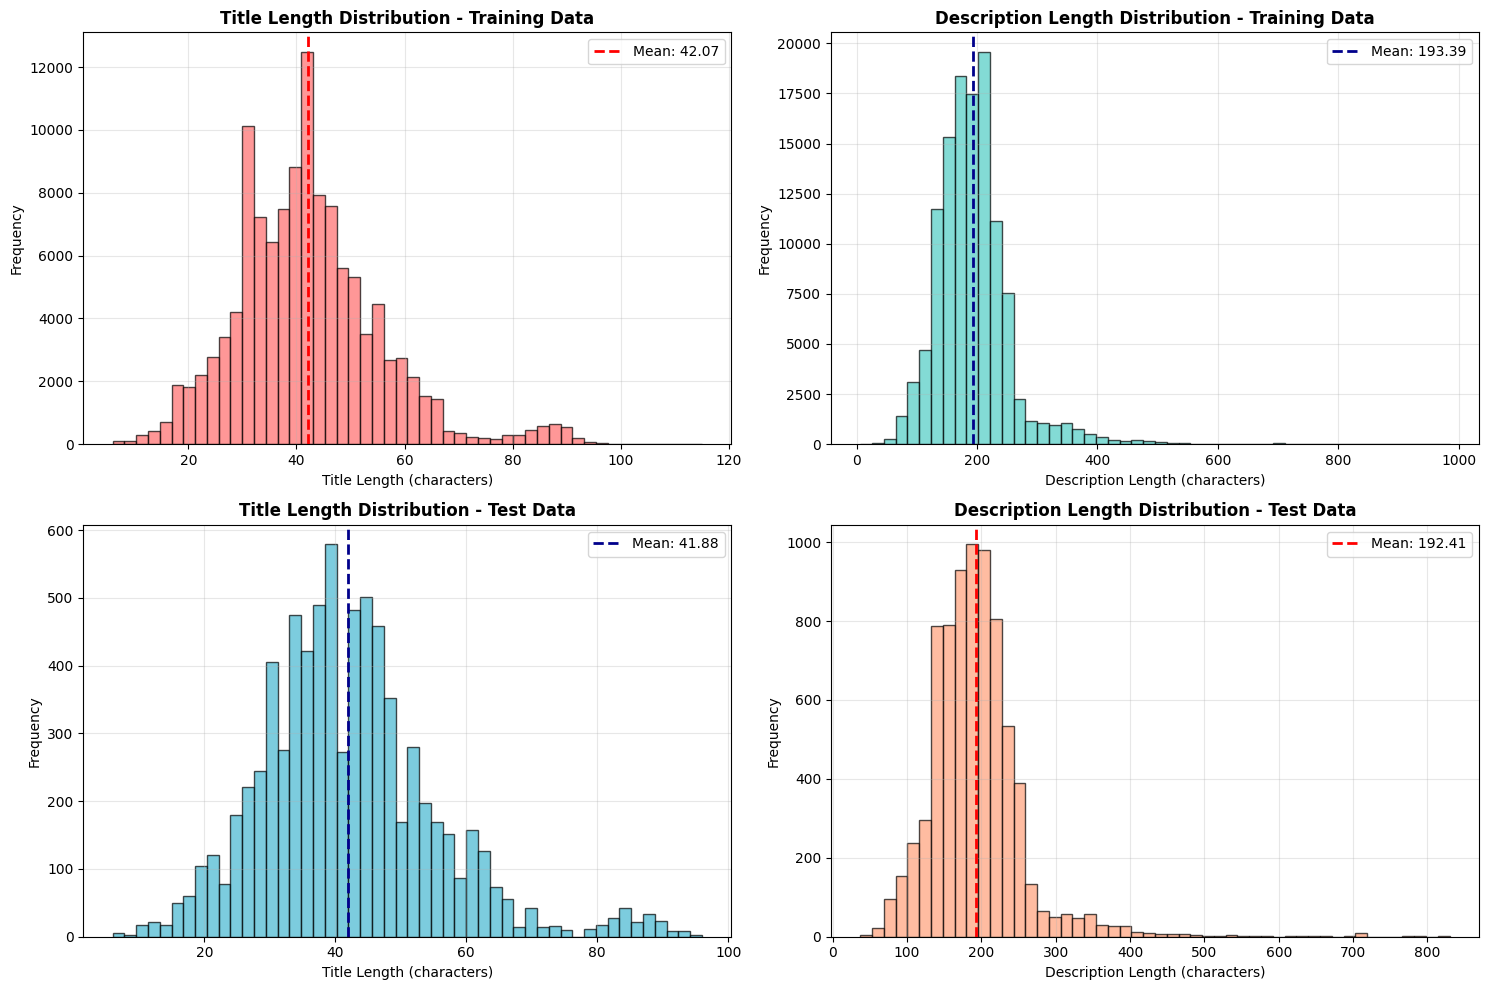


✓ Text length distribution analysis complete!


In [27]:
# Create visualizations for text length distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Training Data - Title Length
axes[0, 0].hist(df_train_text['Title_Length'], bins=50, color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Title Length Distribution - Training Data', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Title Length (characters)', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].axvline(df_train_text['Title_Length'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_train_text['Title_Length'].mean():.2f}")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Training Data - Description Length
axes[0, 1].hist(df_train_text['Description_Length'], bins=50, color='#4ECDC4', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Description Length Distribution - Training Data', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Description Length (characters)', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].axvline(df_train_text['Description_Length'].mean(), color='darkblue', linestyle='--', linewidth=2, label=f"Mean: {df_train_text['Description_Length'].mean():.2f}")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Test Data - Title Length
axes[1, 0].hist(df_test_text['Title_Length'], bins=50, color='#45B7D1', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Title Length Distribution - Test Data', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Title Length (characters)', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].axvline(df_test_text['Title_Length'].mean(), color='darkblue', linestyle='--', linewidth=2, label=f"Mean: {df_test_text['Title_Length'].mean():.2f}")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Test Data - Description Length
axes[1, 1].hist(df_test_text['Description_Length'], bins=50, color='#FFA07A', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Description Length Distribution - Test Data', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Description Length (characters)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].axvline(df_test_text['Description_Length'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_test_text['Description_Length'].mean():.2f}")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Text length distribution analysis complete!")

## Random Samples
Examine random samples from the dataset to sanity-check labels and assess the informativeness of titles and descriptions.

In [28]:
def display_random_samples(df, name, num_samples=5):
    print(f"\n{'='*80}")
    print(f"RANDOM SAMPLES: {name}")
    print(f"{'='*80}\n")
    samples = df.sample(n=min(num_samples, len(df)), random_state=42)
    for idx, (_, row) in enumerate(samples.iterrows(), 1):
        lbl = row['label']
        print(f"Sample {idx}:")
        print(f"  Label: {lbl} - {binary_mapping[lbl]}")
        print(f"  Title: {row['Title']}")
        print(f"  Description: {row['Description']}")
        print(f"  Title Length: {len(row['Title'])} chars | Description Length: {len(row['Description'])} chars")
        print(f"  {'-'*76}\n")

display_random_samples(df_train, "Training Data", num_samples=5)
display_random_samples(df_test,  "Test Data",     num_samples=5)
print(" Random samples displayed successfully!")


RANDOM SAMPLES: Training Data

Sample 1:
  Label: 0 - Non-Sports
  Title: BBC set for major shake-up, claims newspaper
  Description: London - The British Broadcasting Corporation, the world #39;s biggest public broadcaster, is to cut almost a quarter of its 28 000-strong workforce, in the biggest shake-up in its 82-year history, The Times newspaper in London said on Monday.
  Title Length: 44 chars | Description Length: 243 chars
  ----------------------------------------------------------------------------

Sample 2:
  Label: 0 - Non-Sports
  Title: Marsh averts cash crunch
  Description: Embattled insurance broker #39;s banks agree to waive clause that may have prevented access to credit. NEW YORK (Reuters) - Marsh  amp; McLennan Cos.
  Title Length: 24 chars | Description Length: 149 chars
  ----------------------------------------------------------------------------

Sample 3:
  Label: 1 - Sports
  Title: Jeter, Yankees Look to Take Control (AP)
  Description: AP - Derek Jeter tu

# Data Preprocessing

## Text Cleaning
Combine Title and Description, strip HTML entities and noise.

In [29]:
import re

def clean_text(text):
    text = text.replace("&amp;", "&").replace("&lt;", "<").replace("&gt;", ">")
    text = text.replace("&quot;", '"').replace("&#39;", "'").replace(" #39;", "'")
    text = text.replace("\\", " ")
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

def combine_and_clean(df):
    df = df.copy()
    df['text'] = (df['Title'] + " " + df['Description']).apply(clean_text)
    return df

df_train = combine_and_clean(df_train)
df_test  = combine_and_clean(df_test)

print("Sample cleaned texts:")
for t in df_train['text'].head(3):
    print(f"  {t[:120]}")
print("\n Text cleaning complete!")

Sample cleaned texts:
  wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street's dwindling band of ultra-cynics,
  carlyle looks toward commercial aerospace (reuters) reuters - private investment firm carlyle group, which has a reputat
  oil and economy cloud stocks' outlook (reuters) reuters - soaring crude prices plus worries about the economy and the ou

 Text cleaning complete!


## Tokenization & Vocabulary
Build a word-level vocabulary from the training set only (top 30 000 tokens + PAD + UNK).

In [30]:
from collections import Counter

VOCAB_SIZE = 30_000
PAD_TOKEN  = "<PAD>"
UNK_TOKEN  = "<UNK>"
PAD_IDX    = 0
UNK_IDX    = 1

def simple_tokenize(text):
    return text.split()

counter = Counter()
for text in df_train['text']:
    counter.update(simple_tokenize(text))

most_common = counter.most_common(VOCAB_SIZE)
vocab = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
for word, _ in most_common:
    vocab[word] = len(vocab)

print(f"Vocabulary size (incl. PAD/UNK): {len(vocab):,}")

Vocabulary size (incl. PAD/UNK): 30,002


## Sequence Encoding & Padding

In [31]:
MAX_LEN = 128

def encode(text):
    tokens = simple_tokenize(text)[:MAX_LEN]
    ids = [vocab.get(t, UNK_IDX) for t in tokens]
    ids += [PAD_IDX] * (MAX_LEN - len(ids))
    return ids

X_train = np.array([encode(t) for t in df_train['text']], dtype=np.int64)
y_train = df_train['label'].values.astype(np.int64)
X_test  = np.array([encode(t) for t in df_test['text']],  dtype=np.int64)
y_test  = df_test['label'].values.astype(np.int64)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

X_train: (120000, 128)  y_train: (120000,)
X_test:  (7600, 128)   y_test:  (7600,)


## PyTorch DataLoaders

In [32]:
import torch
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_t = torch.tensor(X_train, dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")

Using device: cpu
Train batches: 1875  |  Test batches: 119


# Scratch Model — BiLSTM Binary Classifier

## Model Architecture

In [33]:
import torch.nn as nn

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(emb)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden))

EMBED_DIM  = 128
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT    = 0.3
NUM_EPOCHS = 5
LR         = 1e-3

model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {total_params:,}")

BiLSTMClassifier(
  (embedding): Embedding(30002, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)

Trainable parameters: 4,500,226


## Training Loop

In [34]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=1, factor=0.5, verbose=True)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            total_loss += loss.item() * len(yb)
            correct    += (logits.argmax(dim=1) == yb).sum().item()
            total      += len(yb)
    return total_loss / total, correct / total

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>8}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(test_loader,  train=False)
    scheduler.step(vl_acc)
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)
    print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc:>9.4f}  {vl_loss:>8.4f}  {vl_acc:>8.4f}")

print("\n Training complete!")

 Epoch  Train Loss  Train Acc  Val Loss   Val Acc
-------------------------------------------------------
     1      0.1640     0.9365    0.0765    0.9741
     2      0.0688     0.9766    0.0592    0.9811
     3      0.0475     0.9843    0.0508    0.9833
     4      0.0358     0.9879    0.0572    0.9849
     5      0.0284     0.9906    0.0537    0.9845

 Training complete!


## Training Curves

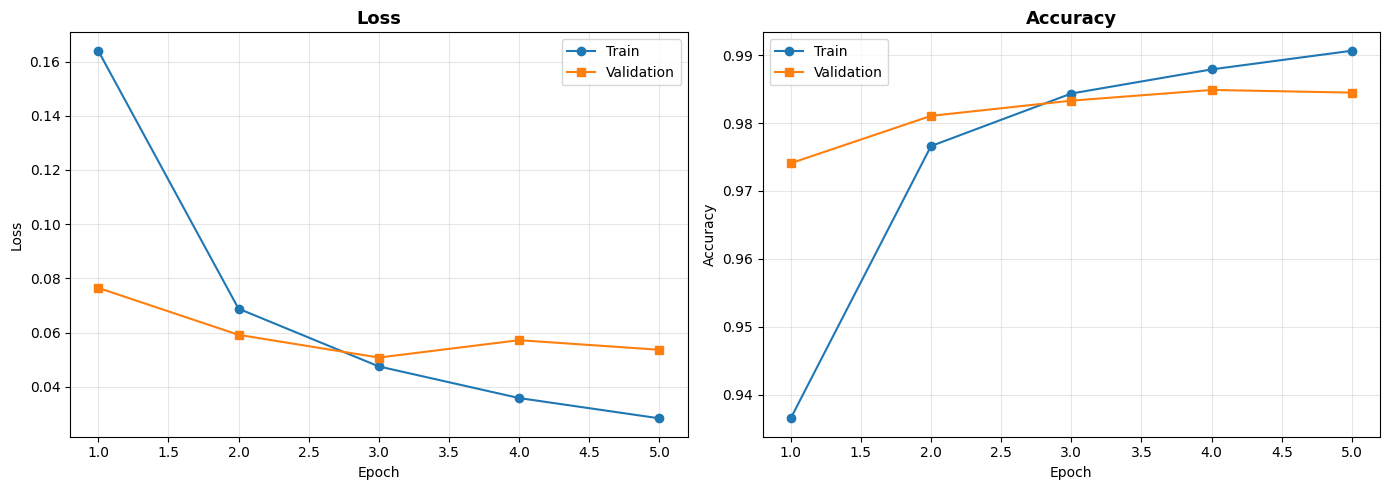

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history["train_loss"], 'o-', label='Train')
axes[0].plot(epochs, history["val_loss"],   's-', label='Validation')
axes[0].set_title('Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], 'o-', label='Train')
axes[1].plot(epochs, history["val_acc"],   's-', label='Validation')
axes[1].set_title('Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluation

## Metrics — Accuracy, Precision, Recall, F1

In [36]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, pos_label=1)
rec  = recall_score(all_labels, all_preds, pos_label=1)
f1   = f1_score(all_labels, all_preds, pos_label=1)

print(f"{'Accuracy' :>12}: {acc:.4f}")
print(f"{'Precision':>12}: {prec:.4f}  (Sports class)")
print(f"{'Recall'   :>12}: {rec:.4f}  (Sports class)")
print(f"{'F1 Score' :>12}: {f1:.4f}  (Sports class)")
print()
print(classification_report(all_labels, all_preds, target_names=["Non-Sports", "Sports"]))

    Accuracy: 0.9845
   Precision: 0.9770  (Sports class)
      Recall: 0.9605  (Sports class)
    F1 Score: 0.9687  (Sports class)

              precision    recall  f1-score   support

  Non-Sports       0.99      0.99      0.99      5700
      Sports       0.98      0.96      0.97      1900

    accuracy                           0.98      7600
   macro avg       0.98      0.98      0.98      7600
weighted avg       0.98      0.98      0.98      7600



## Confusion Matrix

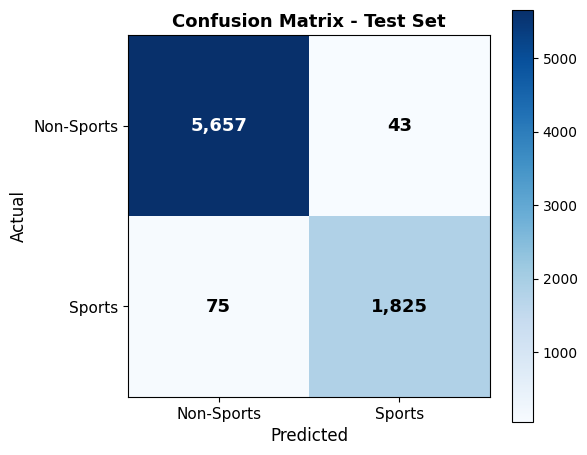

In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

class_names = ["Non-Sports", "Sports"]
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(class_names, fontsize=11)
ax.set_yticklabels(class_names, fontsize=11)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual',    fontsize=12)
ax.set_title('Confusion Matrix - Test Set', fontsize=13, fontweight='bold')

thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Save Model Checkpoint

In [38]:
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab': vocab,
    'hyperparams': {
        'embed_dim': EMBED_DIM, 'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS, 'dropout': DROPOUT,
        'max_len': MAX_LEN, 'vocab_size': len(vocab)
    }
}, 'bilstm_binary_checkpoint.pt')

print(" Model saved to bilstm_binary_checkpoint.pt")

 Model saved to bilstm_binary_checkpoint.pt
